In [58]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [59]:
data_path = Path("..") / "data/raw/training_pop30_genres.parquet"
df = pd.read_parquet(data_path)
print(f"Loaded {len(df):,} tracks from {data_path}")

Loaded 1,863,421 tracks from ../data/raw/training_pop30_genres.parquet


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863421 entries, 0 to 1863420
Data columns (total 34 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   track_rowid             int64  
 1   track_name              object 
 2   artist_name             object 
 3   artist_rowid            int64  
 4   album_rowid             int64  
 5   album_name              object 
 6   album_type              object 
 7   label                   object 
 8   release_date            object 
 9   release_date_precision  object 
 10  id_isrc                 object 
 11  id_upc                  object 
 12  time_signature          int64  
 13  tempo                   float64
 14  key                     int64  
 15  mode                    int64  
 16  danceability            float64
 17  energy                  float64
 18  loudness                float64
 19  speechiness             float64
 20  acousticness            float64
 21  instrumentalness        float64

## Album Type

Nothing to do here

In [61]:
df["album_type"].describe()

count     1863421
unique          3
top         album
freq       993207
Name: album_type, dtype: object

In [62]:
df["album_type"].value_counts()

album_type
album          993207
single         798379
compilation     71835
Name: count, dtype: int64

## Dates

In [63]:
release_date = pd.to_datetime(df["release_date"], format="mixed", errors="coerce")
print(f"there are {release_date.isna().sum()} tracks with bad release date format.")
df[release_date.isna()].head()

there are 66 tracks with bad release date format.


,track_rowid,track_name,artist_name,artist_rowid,album_rowid,album_name,album_type,label,release_date,release_date_precision,...,explicit,track_popularity,artist_popularity,artist_followers,album_popularity,duration_ms,track_number,disc_number,total_tracks,artist_genres
87546,70355741,Думал(а),R.Riccardo,4252945,11962543,Думал(а),single,Артель Медиа,0000,year,...,0,31,41,8199,17,159639,1,1,1,None
101835,86407197,Mka marre malli oj Kosove e jemja,Hamez Llapqeva,2031903,17218969,Mka marre malli oj Kosove e jemja,single,Kosove show,0000,year,...,0,31,19,588,18,252040,1,1,1,None
116009,104962153,Boundless Imagination,Stive Morgan,1960916,21703451,The Crossroads of Time,album,United Music Group,0000,year,...,0,31,41,24430,30,281015,4,1,11,new age
152984,142417707,Сокурская улица,Krafal,7569615,31062305,Сокурская улица,single,Gorky Records,0000,year,...,1,31,23,337,20,150437,1,1,1,None
160241,168362805,Missing,Yasushi Nakanishi,1297768,36770113,スタンダーズ,album,Tokuma Japan C.,0000,year,...,0,31,42,22649,27,238973,3,1,11,j-pop | kayokyoku


In [64]:
drop = release_date.isna()

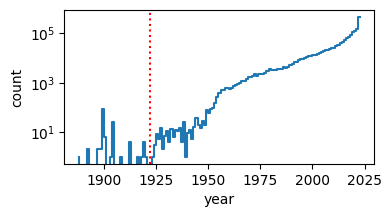

In [65]:
counts, bins = np.histogram(
    _r := release_date[~drop].dt.year, 
    bins=np.arange(_r.min(), _r.max(), 1)
)

plt.figure(figsize=(4,2))
plt.step(bins[:-1], counts)
plt.axvline(1922, linestyle="dotted", c="red")
plt.semilogy(); plt.xlabel("year"); plt.ylabel("count")
plt.show()

In [66]:
year_threshold = 1955
drop = drop | (release_date.dt.year < year_threshold)

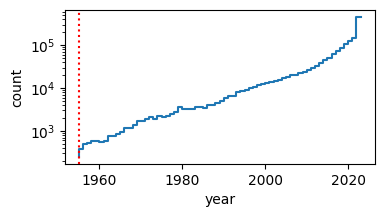

In [67]:
counts, bins = np.histogram(
    _r := release_date[~drop].dt.year, 
    bins=np.arange(_r.min(), _r.max(), 1)
)

plt.figure(figsize=(4,2))
plt.step(bins[:-1], counts)
plt.axvline(year_threshold, linestyle="dotted", c="red")
plt.semilogy(); plt.xlabel("year"); plt.ylabel("count")
plt.show()

In [68]:
print(f"dropping {(_n := drop.sum())} rows ({_n / len(df):.3f} %))")
df = df[~drop].reset_index(drop=True)

dropping 965 rows (0.001 %))


Replace `release_date` and `release_date_precision` with `release_year` and `release_season` columns

In [69]:
def extract_release_features(df: pd.DataFrame) -> pd.DataFrame:
    """Extract release_year and release_season from release_date strings."""
    dt = pd.to_datetime(df["release_date"], format="mixed")

    year = dt.dt.year
    month = dt.dt.month

    season_map = {
        12: "winter", 1: "winter", 2: "winter",
        3: "spring", 4: "spring", 5: "spring",
        6: "summer", 7: "summer", 8: "summer",
        9: "fall", 10: "fall", 11: "fall",
    }
    season = month.map(season_map).fillna("unknown")

    # Set season to "unknown" when release_date_precision is "year"
    # (pd.to_datetime defaults year-only dates to Jan 1st, which would be "winter")
    if "release_date_precision" in df.columns:
        season = season.where(df["release_date_precision"] != "year", "unknown")

    return pd.DataFrame({
        "release_year": year,
        "release_season": season.astype("category"),
    })

_df = extract_release_features(df)
idx = df.columns.get_loc('release_date_precision')
df.insert(idx + 1, '_release_year', _df["release_year"])
df.insert(idx + 2, '_release_season', _df["release_season"])

## Labels

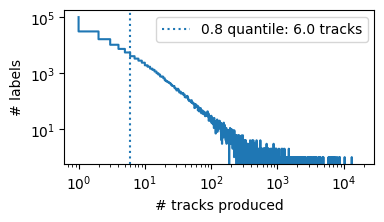

In [70]:
counts, bins = np.histogram(
    _l := df["label"].value_counts(), 
    bins=np.arange(_l.min(), _l.max(), 1)
)

plt.figure(figsize=(4,2))
plt.step(bins[:-1], counts)
plt.axvline(_lq := _l.quantile(0.80), linestyle="dotted", label=f"0.8 quantile: {_lq} tracks")
plt.loglog(); plt.xlabel("# tracks produced"); plt.ylabel("# labels"); plt.legend()
plt.show()

In [71]:
_l = df["label"].value_counts()
for n in range(1, 6):
    q = 1.0 - 0.2 ** n
    _lm = _l > _l.quantile(q)
    _ln = _lm.sum()
    _ltn = _l[_lm].sum()
    print(f"the top {100 * (1 - q):.2f}% labels ({_ln} out of {len(_l)}) produced {_ltn} tracks, or {100 * _ltn / len(df):.2f}% of the dataset.")

the top 20.00% labels (35959 out of 207271) produced 1539375 tracks, or 82.65% of the dataset.
the top 4.00% labels (8066 out of 207271) produced 1174917 tracks, or 63.08% of the dataset.
the top 0.80% labels (1651 out of 207271) produced 821599 tracks, or 44.11% of the dataset.
the top 0.16% labels (332 out of 207271) produced 519123 tracks, or 27.87% of the dataset.
the top 0.03% labels (67 out of 207271) produced 283417 tracks, or 15.22% of the dataset.


In [72]:
_l = df["label"].value_counts()
for label in [
    "Stones Throw Records",
    "Merge Records",
    "Sub Pop Records",
    "Dischord Records",
    "SST Records",
]:
    _ln = _l.loc[label]
    print(f"label {label} produced {_ln} tracks. top {100 * (_l >= _ln).sum() / len(_l):.3f} %")

label Stones Throw Records produced 380 tracks. top 0.228 %
label Merge Records produced 388 tracks. top 0.223 %
label Sub Pop Records produced 1002 tracks. top 0.071 %
label Dischord Records produced 116 tracks. top 0.874 %
label SST Records produced 65 tracks. top 1.658 %


In [73]:
def map_categorical_by_frequency(s: pd.Series, labels: list[str], qsplit: float=0.2) -> pd.Series:
    """
    Map a categorical series based on value frequency quantiles.
    """
    n = len(labels)
    
    counts = s.value_counts()
    thresholds = [counts.quantile(1.0 - qsplit ** i) for i in range(1, n + 1)]
    
    mapping = {}
    for val, cnt in counts.items():
        mapped_val = val
        for i, thresh in enumerate(thresholds):
            if cnt < thresh:
                mapped_val = labels[i]
                break
        mapping[val] = mapped_val
    
    return s.map(mapping)


idx = df.columns.get_loc('label')
df.insert(idx + 1, '_label', map_categorical_by_frequency(df["label"], ["<XS_LABEL>", "<S_LABEL>"]).astype("category"))

In [74]:
print(f"number of labels after censoring small ones is: {len(df["_label"].unique())}")

number of labels after censoring small ones is: 8364


In [18]:
df["_label"].value_counts()

_label
<S_LABEL>                   388868
<XS_LABEL>                  290087
Columbia                     17948
Sony Music Entertainment     13285
RCA Records Label            10381
                             ...  
Mellow & Chill Records          29
Mein Kinderliedergarten         29
Chri$tian Gate$                 29
ООО "Мэйнстрим Продакшн"        29
Gulzaar Chhaniwala              29
Name: count, Length: 8364, dtype: int64

## Time Signature

Nothing to do.

In [19]:
df["time_signature"].describe()

count    1.862456e+06
mean     3.896523e+00
std      4.553539e-01
min      0.000000e+00
25%      4.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: time_signature, dtype: float64

In [20]:
df["time_signature"].value_counts()

time_signature
4    1626070
3     173327
5      42687
1      19407
0        965
Name: count, dtype: int64

## Tempo

Nothing to do.

In [21]:
df["tempo"].describe()

count    1.862456e+06
mean     1.205624e+02
std      3.012970e+01
min      0.000000e+00
25%      9.685200e+01
50%      1.200240e+02
75%      1.399970e+02
max      2.499890e+02
Name: tempo, dtype: float64

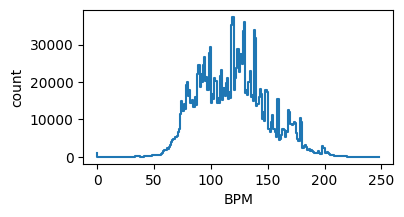

In [22]:
counts, bins = np.histogram(
    _l := df["tempo"], 
    bins=np.arange(_l.min(), _l.max(), 1)
)

plt.figure(figsize=(4,2))
plt.step(bins[:-1], counts)
plt.xlabel("BPM"); plt.ylabel("count")
plt.show()

## Key

Nothing to do.

In [23]:
df["key"].describe()

count    1.862456e+06
mean     5.280413e+00
std      3.585797e+00
min      0.000000e+00
25%      2.000000e+00
50%      5.000000e+00
75%      8.000000e+00
max      1.100000e+01
Name: key, dtype: float64

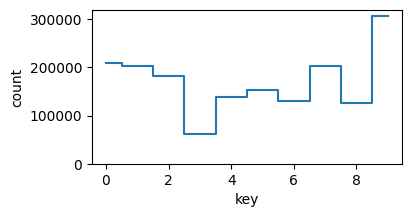

In [24]:
counts, bins = np.histogram(
    _l := df["key"], 
    bins=np.arange(_l.min(), _l.max(), 1)
)

plt.figure(figsize=(4,2))
plt.step(bins[:-1], counts, where="mid")
plt.xlabel("key"); plt.ylabel("count"); plt.ylim(bottom=0)
plt.show()

## Mode

Now I'm curious if 1 is for minor or major..

In [25]:
df["mode"].value_counts()

mode
1    1121083
0     741373
Name: count, dtype: int64

## Loudness

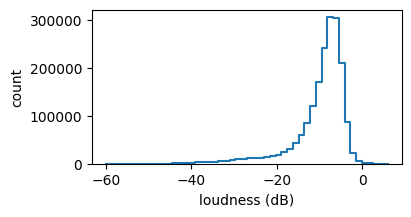

In [26]:
counts, bins = np.histogram(
    df["loudness"], 
    bins=50,
)

plt.figure(figsize=(4,2))
plt.step(bins[:-1], counts, where="mid")
plt.xlabel("loudness (dB)"); plt.ylabel("count"); plt.ylim(bottom=0)
plt.show()

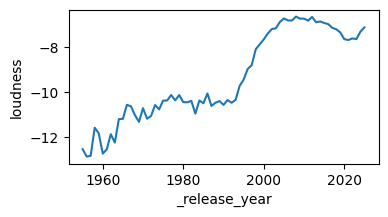

In [27]:
df.groupby("_release_year")["loudness"].median().plot(figsize=(4,2), ylabel="loudness")
plt.show()

Normalizes loudness by year.

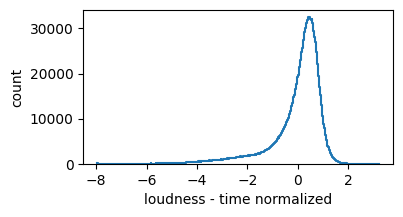

In [28]:
sigma4 = 1 / 15787 / 2
_loudness_normalized = (
    (df["loudness"] - df.groupby("_release_year")["loudness"].transform("mean")) / 
    df.groupby("_release_year")["loudness"].transform("std")
)
_loudness_normalized = _loudness_normalized.clip(_loudness_normalized.quantile(sigma4))
counts, bins = np.histogram(
    _loudness_normalized, 
    bins=500,
)

plt.figure(figsize=(4,2))
plt.step(bins[:-1], counts, where="mid")
plt.xlabel("loudness - time normalized"); plt.ylabel("count"); plt.ylim(bottom=0)
plt.show()

## Audio features

In [29]:
audio_features = ["danceability", "energy", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"]
df[audio_features].describe()

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence
count,1.862456e+06,1.862456e+06,1.862456e+06,1.862456e+06,1.862456e+06,1.862456e+06,1.862456e+06
mean,5.998308e-01,6.001261e-01,1.135788e-01,3.459616e-01,1.559898e-01,2.005118e-01,4.887096e-01
std,1.777097e-01,2.486657e-01,1.528521e-01,3.233294e-01,3.165923e-01,1.717047e-01,2.602129e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.940000e-01,4.460000e-01,3.700000e-02,4.930000e-02,0.000000e+00,9.880000e-02,2.780000e-01
50%,6.230000e-01,6.350000e-01,5.270000e-02,2.430000e-01,1.650000e-05,1.270000e-01,4.860000e-01
75%,7.290000e-01,7.970000e-01,1.140000e-01,6.060000e-01,2.700000e-02,2.510000e-01,6.980000e-01
max,9.990000e-01,1.000000e+00,9.700000e-01,9.960000e-01,1.000000e+00,1.000000e+00,1.000000e+00


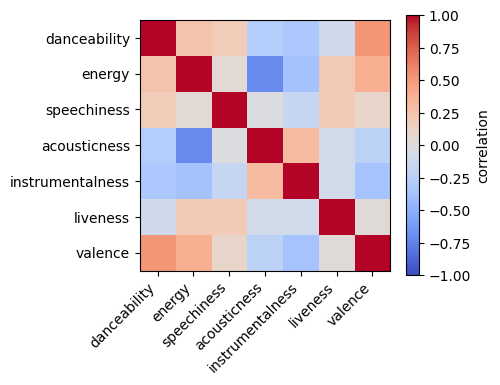

In [30]:
corr = df[audio_features].corr()

plt.figure(figsize=(5, 4))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(audio_features)), audio_features, rotation=45, ha="right")
plt.yticks(range(len(audio_features)), audio_features)
plt.colorbar(label="correlation")
plt.tight_layout()
plt.show()

## Explicit

Nothing to do here.

In [31]:
df["explicit"].describe()

count    1.862456e+06
mean     1.633392e-01
std      3.696749e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: explicit, dtype: float64

In [32]:
df["explicit"].value_counts()

explicit
0    1558244
1     304212
Name: count, dtype: int64

## Track Popularity

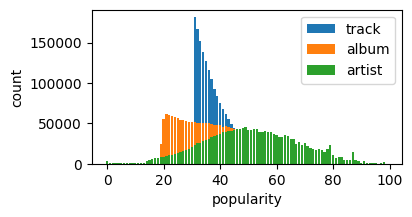

In [33]:
bins = np.arange(0, 101)
tcounts, tbins = np.histogram(
    df["track_popularity"], 
    bins=bins,
)
acounts, abins = np.histogram(
    df["artist_popularity"], 
    bins=bins,
)
dcounts, dbins = np.histogram(
    df["album_popularity"], 
    bins=bins,
)

plt.figure(figsize=(4,2))
plt.bar(tbins[:-1], tcounts, label="track")
plt.bar(dbins[:-1], dcounts, label="album")
plt.bar(abins[:-1], acounts, label="artist")
plt.xlabel("popularity"); plt.ylabel("count"); plt.ylim(bottom=0); plt.legend()
plt.show()

This is kinda cool. Older tracks are on average more popular than newer one. This is likely because of survivor bias.

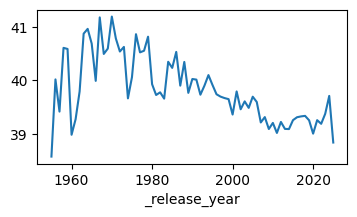

In [34]:
df.groupby("_release_year")["track_popularity"].mean().plot(figsize=(4,2))
plt.show()

Since we are already clipping the dataset based on popularity, we will never get truly obscure garbage music. I believe for V1 is a good idea to remove popularity columns from the training data, at least for measuring their impact on later versions of the recommender.

## Duration

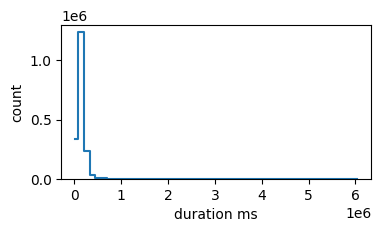

In [35]:
counts, bins = np.histogram(
    df["duration_ms"], 
    bins=50,
)

plt.figure(figsize=(4,2))
plt.step(bins[:-1], counts, where="mid")
plt.xlabel("duration ms"); plt.ylabel("count"); plt.ylim(bottom=0)
plt.show()

Clips duration upper tail.

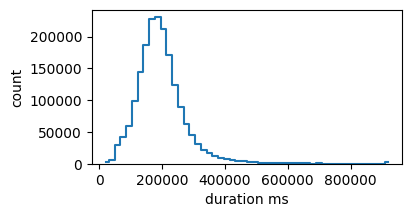

In [36]:
sigma = 1 / 370 / 2
counts, bins = np.histogram(
    df["duration_ms"].clip(upper=df["duration_ms"].quantile(1 - sigma)), 
    bins=50,
)

plt.figure(figsize=(4,2))
plt.step(bins[:-1], counts, where="mid")
plt.xlabel("duration ms"); plt.ylabel("count"); plt.ylim(bottom=0)
plt.show()

## Genres

In [101]:
from collections import Counter


counter = Counter()

def count(xs: list[str]):
    for x in xs:
        counter[x] += 1
    return xs

def replace_under_threshold(xs: list[str], placeholder="<NICHE_GENRE>", threshold=100) -> list[str]:
    return [x if counter[x] > threshold else placeholder for x in xs]

UNKNOWN_GENRE_TOKEN = "<UNKNOWN_GENRE>"
NICHE_GENRE_TOKEN = "<NICHE_GENRE>"
SEPARATOR = " | "
parsed = df["artist_genres"].fillna(UNKNOWN_GENRE_TOKEN).apply(lambda x: x.split(SEPARATOR)).apply(count).apply(lambda xs: replace_under_threshold(xs, NICHE_GENRE_TOKEN))
print(f"Found {len(counter)} different genres and masked {len([g for g, c in counter.items() if c < 100])} niche genres.")

Found 705 different genres and masked 38 niche genres.


In [108]:
from collections import Counter


def genres_fill_and_mask_under_threshold(
    s: pd.Series,
    threshold: int,
    separator: str = " | ",
    unknown_token: str = "<UNKNOWN_GENRE>",
    niche_token: str = "<NICHE_GENRE>",
) -> pd.Series:
    """
    Fill missing genre values and mask infrequent genres.

    Args:
        s: Series containing delimited genre strings (e.g., "rock | pop | indie").
        threshold: Genres appearing <= this many times are replaced with niche_token.
        separator: Delimiter used to split genre strings.
        unknown_token: Token for missing/null values.
        niche_token: Token to replace infrequent genres.

    Returns:
        Series of lists with infrequent genres masked.
    """
    counter = Counter()

    def count(xs: list[str]):
        for x in xs:
            counter[x] += 1
        return xs
    
    def mask_rare(genres: list[str]) -> list[str]:
        return [g if counter[g] > threshold else niche_token for g in genres]

    return s.fillna(unknown_token).apply(lambda x: x.split(separator)).apply(count).apply(lambda xs: mask_rare(xs)).apply(str)

genres_fill_and_mask_under_threshold(df["artist_genres"], 100)

0                                        ['<UNKNOWN_GENRE>']
1                                        ['<UNKNOWN_GENRE>']
2                                        ['<UNKNOWN_GENRE>']
3                                        ['<UNKNOWN_GENRE>']
4                                    ['dansband', 'epadunk']
                                 ...                        
1862451                    ['hip hop', 'west coast hip hop']
1862452    ['latin', 'reggaeton', 'trap latino', 'urbano ...
1862453                                  ['<UNKNOWN_GENRE>']
1862454    ['latin', 'reggaeton', 'trap latino', 'urbano ...
1862455                                   ['art pop', 'pop']
Name: artist_genres, Length: 1862456, dtype: object